# Comparativa Global de Algoritmos de Aprendizaje por Refuerzo en Entornos Complejos

Este notebook realiza una comparación exhaustiva entre algoritmos de **Monte Carlo** y **Diferencia Temporal (TD)** aplicados al entorno **FrozenLake 4x4**.

El objetivo es analizar y visualizar el rendimiento de los siguientes algoritmos:
1.  **Monte Carlo On-Policy (First Visit & Every Visit)**: Métodos de control Monte Carlo on-policy.
2.  **Monte Carlo Off-Policy (Weighted Importance Sampling)**: Método de control Monte Carlo off-policy utilizando muestreo por importancia ponderado.
3.  **SARSA**: Algoritmo de control TD On-Policy (State-Action-Reward-State-Action).
4.  **Q-Learning**: Algoritmo de control TD Off-Policy.
5.  **Double Q-Learning**: Variante de Q-Learning diseñada para reducir la sobreestimación de los valores de acción.

Se evaluarán dos métricas principales:
*   **Proporción de Recompensa (Success Rate)**: Evolución del retorno promedio acumulado.
*   **Longitud de Episodios**: Número de pasos necesarios para completar cada episodio.

### 1. Importación de Librerías y Configuración
En esta celda se importan las bibliotecas necesarias:
*   **Librerías estándar y científicas**: `numpy`, `pandas`, `matplotlib` para cálculo y gráficos.
*   **Gymnasium**: Para la instanciación de los entornos de RL.
*   **Torch**: Para el manejo de tensores y operaciones en GPU (si aplica).
*   **Agentes propios**: Se importan las clases de los agentes implementados en la carpeta `src/agents`, cubriendo algoritmos desde Monte Carlo hasta Deep Q-Learning.

In [1]:
# Importamos librerias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import gymnasium as gym
import random
import torch
import gc
import os
import sys

# Aseguramos que el directorio raíz está en el path para importar módulos locales
sys.path.append(os.getcwd())

# Importamos las clases de los agentes desde src
# Monte Carlo
from src.agents.AgenteMC_OnPolicy import AgenteMC_OnPolicy
from src.agents.AgenteMC_OffPolicy import AgenteMC_OffPolicy

# Diferencia Temporal
from src.agents.AgenteDT_Sarsa import AgenteDT_Sarsa
from src.agents.AgenteDT_QL import AgenteDT_QL
from src.agents.AgenteDT_Double_QL import AgenteDT_Double_QL

# Metodos Aproximados (Aunque no los usaremos para entrenamiento, los dejamos si luego se requieren)
from src.agents.AgenteDT_SarsaSG import AgenteDT_SarsaSG
from src.agents.AgenteDT_Deep_QL import AgenteDT_DeepQL
from src.agents.AgenteDT_Double_Deep_QL import AgenteDT_DobleDeepQL
from src.tilings.tiling import TileCodingEnv

from src.ploting import *

### 2. Configuración del Entorno de Ejecución
Se configura el hardware (CPU o GPU) y se establece una **semilla (seed)** global. 
Esto es crucial para garantizar la **reproducibilidad** de los experimentos, asegurando que la aleatoriedad inicial (pesos de red, exploración inicial) sea la misma en cada ejecución.

In [2]:
# Configuración del dispositivo (CPU o GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

# Liberación de memoria
gc.collect()
torch.cuda.empty_cache()

# Configuración de la semilla para reproducibilidad
seed = 2024
np.random.seed(seed)
np.random.default_rng(seed)
os.environ['PYTHONHASHSEED'] = str(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

Usando dispositivo: cpu


### 3. Inicialización de Entornos FrozenLake
Se crean dos instancias del entorno **FrozenLake**:
*   **4x4**: Mapa pequeño convencional.
*   **8x8**: Mapa más grande y complejo.

**Nota**: Se usa `is_slippery=False`, lo que elimina la estocasticidad en las transiciones (el agente siempre se mueve a la celda deseada). Esto simplifica el problema a uno determinista, facilitando la validación del aprendizaje de los algoritmos básicos.

In [3]:
# Configuración del Entorno FrozenLake 4x4
# Usamos map_name="4x4" y is_slippery=False para un entorno determinista y más fácil de analizar.
name_env = 'FrozenLake-v1'
render = "rgb_array"
# Establecemos un límite de pasos razonable para evitar bucles infinitos en políticas iniciales
env_4x4 = gym.make(name_env, is_slippery=False, map_name="4x4", render_mode=render, max_episode_steps=500)
env_8x8 = gym.make(name_env, is_slippery=False, map_name="8x8", render_mode=render, max_episode_steps=500) # Más pasos para 8x8
print("Entornos FrozenLake 4x4 y 8x8 (is_slippery=False) inicializados.")

Entornos FrozenLake 4x4 y 8x8 (is_slippery=False) inicializados.


### 4. Funciones de Entrenamiento: Monte Carlo
Se definen las funciones para ejecutar episodios completos bajo el paradigma Monte Carlo:
*   **`monte_carlo_all_visit`**: Actualiza el valor de los estados basándose en *todos* los retornos obtenidos tras visitar un estado en un episodio.
*   **`monte_carlo_first_visit`**: Solo considera el retorno acumulado tras la *primera* visita a un estado en el episodio.

Ambas funciones almacenan el historial de recompensas y longitudes de episodio para su posterior análisis.

In [4]:
# Funciones de Ejecución para Monte Carlo

def monte_carlo_all_visit(env, agente, num_episodes=5000):
    stats = 0.0
    list_stats = [stats]
    all_episode_lengths = [] 
    step_display = max(1, num_episodes // 10)

    for t in tqdm(range(num_episodes), desc="MC All Visit"):
        state, info = env.reset(seed=seed)
        done = False
        episode = []
        result_sum  = 0.0
        while not done:
            action = agente.get_action(state, t)
            new_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            result_sum += reward
            # Guardamos el estado, la acción y la recompensa INMEDIATA
            episode.append((state, action, reward))
            state = new_state

        # Fase de actualización: Iteramos en orden inverso (delegado al agente)
        agente.update(episode)    
        # Guardamos datos sobre la evolución
        stats += result_sum
        list_stats.append(stats / (t + 1))
        all_episode_lengths.append(len(episode))

    return list_stats, all_episode_lengths

def monte_carlo_first_visit(env, agente, num_episodes=5000):
    stats = 0.0
    list_stats = [stats]
    all_episode_lengths = [] 
    step_display = max(1, num_episodes // 10)
    num_goal = 0

    for t in tqdm(range(num_episodes), desc="MC First Visit"):
        state, info = env.reset(seed=seed)
        done = False
        episode = []
        result_sum  = 0.0
        while not done:
            action = agente.get_action(state, t)
            new_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            if reward == 1.0:
                num_goal += 1
            # Guardamos el estado, la acción y la recompensa
            result_sum += reward
            episode.append((state, action, reward))
            state = new_state

        # Primera visita (delegado al agente)
        agente.update_first_visit(episode)    
        # Guardamos datos sobre la evolución
        stats += result_sum
        list_stats.append(stats / (t + 1))
        all_episode_lengths.append(len(episode))

    return list_stats, all_episode_lengths

### 5. Funciones de Entrenamiento: Diferencia Temporal (TD)
Se definen los bucles de entrenamiento para métodos de *bootstrapping*:
*   **`diferencia_temporal`**: Función genérica para algoritmos como **SARSA** y **Q-Learning/Double Q-Learning**. La diferencia principal radica en cómo el agente calcula `new_action` o actualiza sus valores Q internamente (On-Policy vs Off-Policy).
*   **`entrenamientoDeepQL`**: Bucle diseñado para agentes con aproximación de funciones (Deep RL). Incluye el buffer de experiencia (`save_experience`) y pasos de optimización de la red neuronal.

In [5]:
# Función de Ejecución para Diferencia Temporal (Sarsa / Q-Learning)

def diferencia_temporal(env, agente, num_episodes=5000, label="TD"):
    stats = 0.0
    list_stats = [stats]
    all_episode_lengths = [] 
    step_display = max(1, num_episodes // 10)

    for t in tqdm(range(num_episodes), desc=label):
        state, info = env.reset(seed=seed)
        done = False
        result_sum  = 0.0
        steps = 0
        
        # Obtenemos acción inicial (necesaria para SARSA)
        action = agente.get_action(state, t)
        
        while not done:
            new_state, reward, terminated, truncated, info = env.step(action)
            # Obtenemos siguiente acción (para SARSA; Q-Learning ignorará esto en su update interno)
            new_action = agente.get_action(new_state, t)

            done = terminated or truncated
            
            # Actualizamos el agente
            # Nota: Para Q-Learning 'new_action' no se usa realmente en la fórmula de update, 
            # pero se pasa por compatibilidad de interfaz si la función es genérica.
            agente.update(state, action, reward, new_state, new_action, done)
            
            result_sum += reward
            state = new_state
            action = new_action
            steps += 1

        stats += result_sum
        list_stats.append(stats / (t + 1))
        all_episode_lengths.append(steps)

    return list_stats, all_episode_lengths

# Función de Ejecución para Métodos Aproximados (SarsaSG / Deep Q-Learning)
def entrenamientoDeepQL(tcenv, agente, num_episodes=5000, target_update_freq=500):
    stats = 0.0
    list_stats = []
    all_episode_lengths = [] 
    step_display = max(1, num_episodes // 10)
    
    global_step = 0 # Añadimos un contador global de pasos
    
    for t in tqdm(range(num_episodes)):
        # Asumo que `seed` está definida globalmente en tu script
        state, info = tcenv.reset(seed=seed) 
        done = False
        episode = []
        result_sum  = 0.0
        c = 0
        
        while not done:
            action = agente.get_action(state, t)
            new_state, reward, terminated, truncated, _ = tcenv.step(action)
            done = truncated or terminated
            
            # Guardamos la experiencia
            episode.append((state, action, reward))
            agente.save_experience(state, action, reward, new_state, done)
            
            # --- EL CAMBIO CRÍTICO: ENTRENAR DENTRO DEL BUCLE ---
            # Ahora la red aprende en cada paso (o cuando el batch tenga tamaño suficiente)
            agente.update()
            
            # --- ACTUALIZACIÓN DE RED OBJETIVO POR PASOS ---
            if global_step % target_update_freq == 0 and global_step > 0:
                agente.update_target_network()
            
            result_sum += reward
            state = new_state
            c += 1
            global_step += 1
            
        # Guardamos datos sobre la evolución
        stats += result_sum
        list_stats.append(stats / (t + 1))
        all_episode_lengths.append(len(episode))

        if t % step_display == 0 and t != 0:
            print(f"Episode: {t}, Avg Return: {stats/t:.2f}, Epsilon: {agente.epsilon:.3f}")

    return list_stats, all_episode_lengths

### 6. Orquestador de Experimentos
La función **`ejecutar_experimentos`** automatiza la ejecución secuencial de los distintos algoritmos (MC, SARSA, QL, DQL) sobre un mismo entorno.
Recibe un diccionario de parámetros (`params`) que define hiperparámetros específicos (epsilon, factor de descuento, tasa de decaimiento) para cada modelo, facilitando la comparación bajo condiciones controladas.

In [6]:
# Función para ejecutar todos los experimentos en un entorno dado
def ejecutar_experimentos(env, env_name, params):
    # Extraemos parámetros generales
    num_episodes = params.get('num_episodes', 5000)
    
    # Diccionario para guardar resultados
    results = {}

    print(f"\n--- Iniciando experimentos para {env_name} ---")

    # 1. Monte Carlo On-Policy (All Visit)
    if 'MC_All_Visit' in params:
        p = params['MC_All_Visit']
        print(f"[{env_name}] Entrenando MC All Visit...")
        agente_mc_all = AgenteMC_OnPolicy(
            env, seed, 
            num_episodes=num_episodes, 
            epsilon=p.get('epsilon', 0.4), 
            discount_factor=p.get('discount_factor', 1.0), 
            decay=p.get('decay', True)
        )
        stats_mc_all, lengths_mc_all = monte_carlo_all_visit(env, agente_mc_all, num_episodes)
        results['MC All Visit'] = {'stats': stats_mc_all, 'lengths': lengths_mc_all}

    # 2. Monte Carlo On-Policy (First Visit)
    if 'MC_First_Visit' in params:
        p = params['MC_First_Visit']
        print(f"[{env_name}] Entrenando MC First Visit...")
        agente_mc_first = AgenteMC_OnPolicy(
            env, seed, 
            num_episodes=num_episodes, 
            epsilon=p.get('epsilon', 0.4), 
            discount_factor=p.get('discount_factor', 1.0), 
            decay=p.get('decay', True)
        )
        stats_mc_first, lengths_mc_first = monte_carlo_first_visit(env, agente_mc_first, num_episodes)
        results['MC First Visit'] = {'stats': stats_mc_first, 'lengths': lengths_mc_first}

    # 3. Monte Carlo Off-Policy (Weighted Importance Sampling)
    if 'MC_Off_Policy' in params:
        p = params['MC_Off_Policy']
        print(f"[{env_name}] Entrenando MC Off-Policy...")
        agente_mc_off = AgenteMC_OffPolicy(
            env, seed, 
            num_episodes=num_episodes, 
            epsilon=p.get('epsilon', 0.4), 
            discount_factor=p.get('discount_factor', 0.9), 
            decay=p.get('decay', True)
        )
        stats_mc_off, lengths_mc_off = monte_carlo_all_visit(env, agente_mc_off, num_episodes)
        results['MC Off-Policy'] = {'stats': stats_mc_off, 'lengths': lengths_mc_off}

    # 4. SARSA
    if 'SARSA' in params:
        p = params['SARSA']
        print(f"[{env_name}] Entrenando SARSA...")
        agente_sarsa = AgenteDT_Sarsa(
            env, seed, 
            num_episodes=num_episodes, 
            epsilon=p.get('epsilon', 0.4), 
            discount_factor=p.get('discount_factor', 0.9), 
            decay=p.get('decay', True), 
            decay_rate=p.get('decay_rate', 4000.0)
        )
        stats_sarsa, lengths_sarsa = diferencia_temporal(env, agente_sarsa, num_episodes, label="SARSA")
        results['SARSA'] = {'stats': stats_sarsa, 'lengths': lengths_sarsa}

    # 5. Q-Learning
    if 'Q_Learning' in params:
        p = params['Q_Learning']
        print(f"[{env_name}] Entrenando Q-Learning...")
        agente_ql = AgenteDT_QL(
            env, seed, 
            num_episodes=num_episodes, 
            epsilon=p.get('epsilon', 0.4), 
            discount_factor=p.get('discount_factor', 0.9), 
            decay=p.get('decay', True), 
            decay_rate=p.get('decay_rate', 500.0)
        )
        stats_ql, lengths_ql = diferencia_temporal(env, agente_ql, num_episodes, label="Q-Learning")
        results['Q-Learning'] = {'stats': stats_ql, 'lengths': lengths_ql}

    # 6. Double Q-Learning
    if 'Double_Q_Learning' in params:
        p = params['Double_Q_Learning']
        print(f"[{env_name}] Entrenando Double Q-Learning...")
        agente_dql = AgenteDT_Double_QL(
            env, seed, 
            num_episodes=num_episodes, 
            epsilon=p.get('epsilon', 0.4), 
            discount_factor=p.get('discount_factor', 0.9), 
            decay=p.get('decay', True), 
            decay_rate=p.get('decay_rate', 500.0)
        )
        stats_dql, lengths_dql = diferencia_temporal(env, agente_dql, num_episodes, label="Double Q-Learning")
        results['Double Q-Learning'] = {'stats': stats_dql, 'lengths': lengths_dql}
    
    return results


### 7. Ejecución de Comparativa en FrozenLake
Se definen los diccionarios de hiperparámetros y se lanzan los experimentos para:
1.  **FrozenLake 4x4**: 10,000 episodios.
2.  **FrozenLake 8x8**: 30,000 episodios (requiere más exploración dada la mayor dimensionalidad).

Se evalúan algoritmos tabulares clásicos: MC (All Visit, Off-Policy), SARSA, Q-Learning y Double Q-Learning.

In [7]:

# Definición de parámetros para 4x4
params_4x4 = {
    'num_episodes': 10000,
    'MC_All_Visit': {'epsilon': 0.4, 'discount_factor': 0.99, 'decay': True, 'decay_rate': 1000.0},
    'MC_Off_Policy': {'epsilon': 0.4, 'discount_factor': 0.9, 'decay': True, 'decay_rate': 1000.0},
    'SARSA': {'epsilon': 0.4, 'discount_factor': 0.9, 'decay': True, 'decay_rate': 500.0},
    'Q_Learning': {'epsilon': 0.4, 'discount_factor': 0.9, 'decay': True, 'decay_rate': 500.0},
    'Double_Q_Learning': {'epsilon': 0.4, 'discount_factor': 0.9, 'decay': True, 'decay_rate': 500.0}
}

# Ejecutamos experimentos para 4x4
results_4x4 = ejecutar_experimentos(env_4x4, "FrozenLake 4x4", params_4x4)

# Definición de parámetros para 8x8
params_8x8 = {
    'num_episodes': 30000,
    'MC_All_Visit': {'epsilon': 0.4, 'discount_factor': 0.99, 'decay': True, 'decay_rate': 1000.0},
    'MC_Off_Policy': {'epsilon': 0.4, 'discount_factor': 0.99, 'decay': True, 'decay_rate': 1000.0},
    'SARSA': {'epsilon': 0.4, 'discount_factor': 0.9, 'decay': True, 'decay_rate': 4000.0},
    'Q_Learning': {'epsilon': 0.4, 'discount_factor': 0.9, 'decay': True, 'decay_rate': 500.0},
    'Double_Q_Learning': {'epsilon': 0.4, 'discount_factor': 0.9, 'decay': True, 'decay_rate': 500.0}
}

# Ejecutamos experimentos para 8x8
results_8x8 = ejecutar_experimentos(env_8x8, "FrozenLake 8x8", params_8x8)


--- Iniciando experimentos para FrozenLake 4x4 ---
[FrozenLake 4x4] Entrenando MC All Visit...


MC All Visit: 100%|██████████| 10000/10000 [00:05<00:00, 1968.47it/s]


[FrozenLake 4x4] Entrenando MC Off-Policy...


MC All Visit: 100%|██████████| 10000/10000 [00:03<00:00, 2604.60it/s]


[FrozenLake 4x4] Entrenando SARSA...


...

SARSA: 100%|██████████| 30000/30000 [00:28<00:00, 1050.40it/s]


[FrozenLake 8x8] Entrenando Q-Learning...


Q-Learning: 100%|██████████| 30000/30000 [00:36<00:00, 815.85it/s]


[FrozenLake 8x8] Entrenando Double Q-Learning...


Double Q-Learning: 100%|██████████| 30000/30000 [00:38<00:00, 775.88it/s]


### 8. Visualización de Resultados (Tabular)
Se grafican las **longitudes de episodio** suavizadas (media móvil). 
*   Una curva decreciente indica que el agente está aprendiendo a llegar a la meta en menos pasos (ruta más óptima).
*   Se compara el rendimiento entre los distintos algoritmos para ver cuál converge más rápido a la solución óptima.

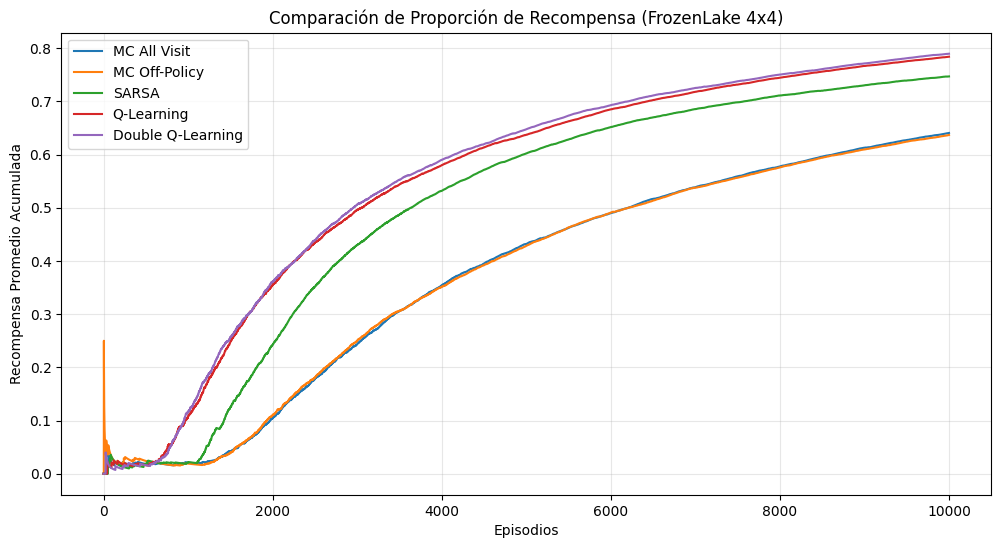

Rendimiento final (Promedio Acumulado) - FrozenLake 4x4:
MC All Visit: 0.6408
MC Off-Policy: 0.6370
SARSA: 0.7471
Q-Learning: 0.7842
Double Q-Learning: 0.7898


In [17]:
plot_rewards(results_4x4, "FrozenLake 4x4")

En cuanto a la gráfica de la recompensa promedia de cada algoritmo en **FrozenLake 4x4**, podemos sacar lo siguiente:
- **Monte Carlo (All y First Visit)**: Presentan un aprendizaje más lento e inestable comparado con los métodos de diferencias temporales, oscilando mucho al principio como se ve en ese pico inical, quedandose por detras de los métodos Q-Learning y Doble Q-Learning.
- **SARSA**: Muestra un aprendizaje más lento que los algoritmos de Q-learning, aunque mejora a los de montecarlo.
- **Q-Learning / Double Q-Learning**: Convergen mucho más rápido a la solución óptima, con una curva de crecimiento de recompensa más pronunciada desde el inicio.

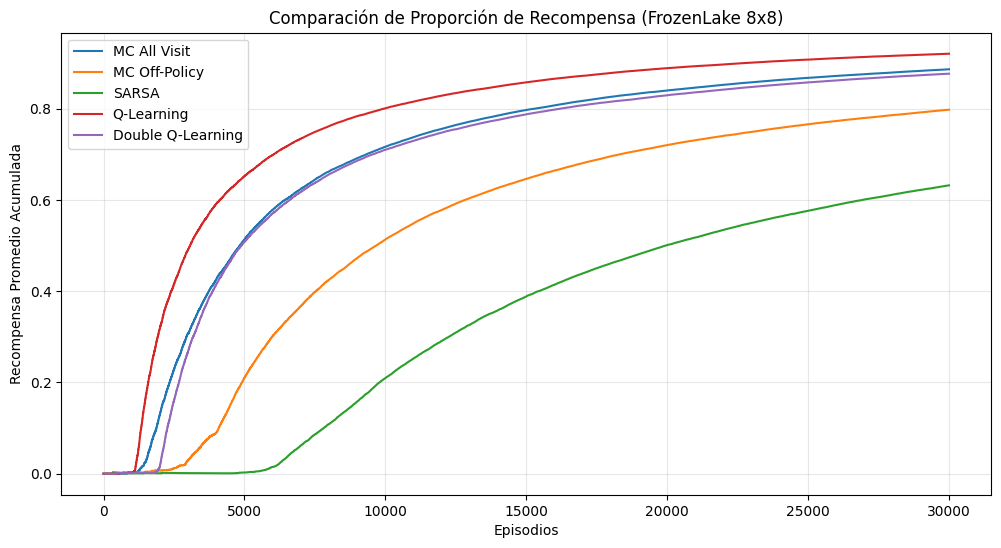

Rendimiento final (Promedio Acumulado) - FrozenLake 8x8:
MC All Visit: 0.8867
MC Off-Policy: 0.7980
SARSA: 0.6322
Q-Learning: 0.9208
Double Q-Learning: 0.8770


In [18]:
plot_rewards(results_8x8, "FrozenLake 8x8")



En el caso de **FrozenLake 8x8**, la complejidad aumenta considerablemente:
- **Monte Carlo**: La versión on-policy (línea azul) obtiene unos resultados similares a Doble Q-Learning, mientras que la versión off-policy (línea naranja) se queda por debajo. Esto se debe a que al ser un problema más complejo con más estados, la necesidad de conocer los pasos anteriores se hace más notable.
- **SARSA**: Debido a que tuvimos que aumentar el ratio de dacay al no encontrar solución con menos, se convierte en el algoritmo que más lento aprende de los analizados en este problema.
- **Q-Learning y Doble Q-Learning**: Mientras que Doble Q-Learning obtiene unos resultados similares a MonteCarlo on-policy, Q-Learning logra aprender más rápido, dando a enteder que este problema no requiere de tanta complejidad de algoritmo para resolverlo.

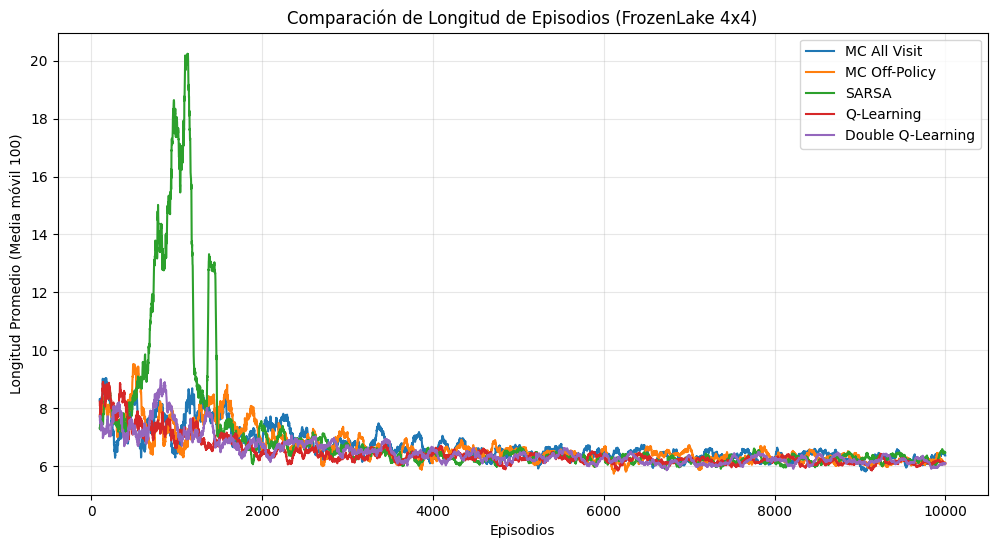

In [19]:
# Plot 4x4
plot_lengths_comparison(results_4x4, "FrozenLake 4x4", window_size=100)

En cuanto a la gráfica de la longitud promedia por episodio de cada algoritmo en **FrozenLake 4x4**, podemos sacar lo siguiente:
- **SARSA**: A diferencia del resto de algoritmos, SARSA es el único algoritmo que cuenta con muchos más pasos por episodio al inicio, pudiendo deberse a que se quede pillado en algun punto al no tener un epsilon lo suficientemente alto para explorar.
- **Resto de algoritmos**: El resto de algororitmos cuentan con similares evoluciones de longitudes de episodios, pudiendo ser por la poca cantidad de estados.



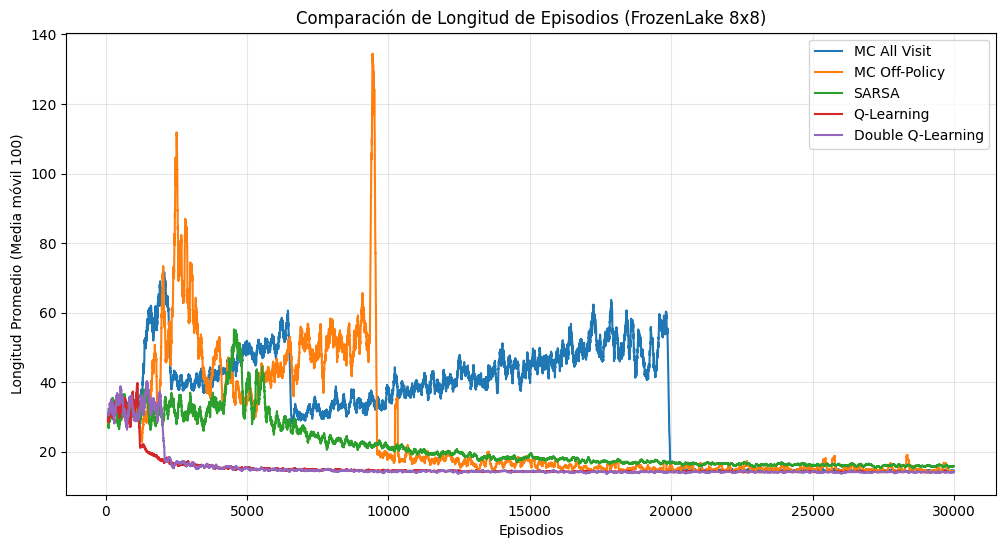

In [20]:
# Plot 8x8
plot_lengths_comparison(results_8x8, "FrozenLake 8x8", window_size=100)

Para **FrozenLake 8x8**:
- **MonteCarlo**: Tanto MonteCarlo on-policy como off-policy, sobre todo este, cuenta con una evolucón con varios picos, lo que pueden ser algunos episodios donde el agente se quedaba pillado en algun punto dando vueltas o en algún extremos. Además, son los que más tardan en encontrar el camino con el menor numero de pasos.
- **SARSA**: Aunque no tenga los mismo picos que MonteCarlo, si tiene un comportamiento similar, además de que una vez encuentra el objetivo, no logra explotar el camino óptimo y tarda más en llegar a ese camino óptimo.
- **Q-Learning y Double Q-Learning**: Son los más eficientes en reducir esta longitud, dando lugar a que son los que menos pasos realizan y encuentran la solución correcta los primeros, sobre todo Q-Learning.

# Comparativa en MountainCar-v0 (Métodos Aproximados)

En esta sección, comparamos algoritmos que utilizan aproximación de funciones para resolver el entorno continuo **MountainCar-v0**.
Utilizamos **Tile Coding** para discretizar el espacio de estados.

Algoritmos comparados:
1.  **Semi-Gradient SARSA**: SARSA con aproximación lineal.
    - **Factor de descuento (alpha)**: 0.99
    - **Epsilon Inicial**: 1.0
    - **Epsilon Decay**: Activado 
    - **Ratio de decay**: cada 200 episodios
2.  **Deep Q-Learning**: Q-Learning con redes neuronales.
    - **Factor de descuento (alpha)**: 0.99
    - **Epsilon Inicial**: 0.5
    - **Epsilon Decay**: Activado 
    - **Ratio de decay**: cada 100 episodios
3.  **Double Deep Q-Learning**: Variante de Deep Q-Learning para reducir sobreestimación.
    - **Factor de descuento (alpha)**: 0.99
    - **Epsilon Inicial**: 0.5
    - **Epsilon Decay**: Activado 
    - **Ratio de decay**: cada 200 episodios

Los resultados de entrenamiento de estos algoritmos han sido pre-calculados y almacenados en un archivo CSV para facilitar su visualización y comparación directa sin necesidad de re-entrenar modelos costosos computacionalmente.


## 1. Carga y Visualización de Resultados Complejos

A continuación, cargamos los datos de `resultados_metodos_aproximados.csv` (o similar) para reconstruir las curvas de aprendizaje.


In [10]:
# Función para cargar resultados desde CSV y formatear para plotting
def cargar_resultados_csv(filename):
    """
    Carga los resultados de un fichero CSV y los devuelve en el diccionario 'results'
    esperado por las funciones de plot_rewards y plot_lengths.
    Estructura CSV esperada columns: Algorithm, Episode, Average_Reward, Episode_Length
    """
    results = {}
    
    if not os.path.exists(filename):
        print(f"Error: El archivo {filename} no existe.")
        return results
        
    print(f"Cargando resultados de {filename}...")
    df = pd.read_csv(filename)
    
    # Obtenemos la lista de algoritmos únicos
    algorithms = df['Algorithm'].unique()
    
    for algo in algorithms:
        df_algo = df[df['Algorithm'] == algo]
        
        # Debemos asegurar que estén ordenados por episodio
        df_algo = df_algo.sort_values('Episode')
        
        stats = df_algo['Average_Reward'].values
        lengths = df_algo['Episode_Length'].values
        
        results[algo] = {
            'stats': stats, 
            'lengths': lengths
        }
        print(f" -> Cargado {algo}: {len(stats)} episodios.")
        
    return results

# Cargamos los datos
# Asumimos que el archivo generado en el otro notebook se llama "resultados_metodos_aproximados.csv"
# Si está en una subcarpeta, ajustar ruta.
filename_csv = "resultados_metodos_aproximados.csv" 
# Intento de encontrarlo si no está en la raíz
if not os.path.exists(filename_csv) and os.path.exists("Entornos_Complejos/resultados_metodos_aproximados.csv"):
     filename_csv = "Entornos_Complejos/resultados_metodos_aproximados.csv"

results_mountaincar = cargar_resultados_csv(filename_csv)

Cargando resultados de resultados_metodos_aproximados.csv...
 -> Cargado SARSA_SG: 5000 episodios.
 -> Cargado Deep_Q-Learning: 5000 episodios.
 -> Cargado Double Deep Q-Learning: 5000 episodios.


## 2. Análisis de Resultados en Continuous State Space

De igual forma que para FrozenLake, comparamos curvas de:
1.  **Recompensa Acumulada**: Indicaría la velocidad de convergencia o estabilidad de la solución.
2.  **Longitud de Episodios**: Métrica crítica en *MountainCar*, donde menos pasos significan que el coche sale más rápido del valle.

Estos gráficos muestran la eficiencia comparativa de los tres métodos aproximados.


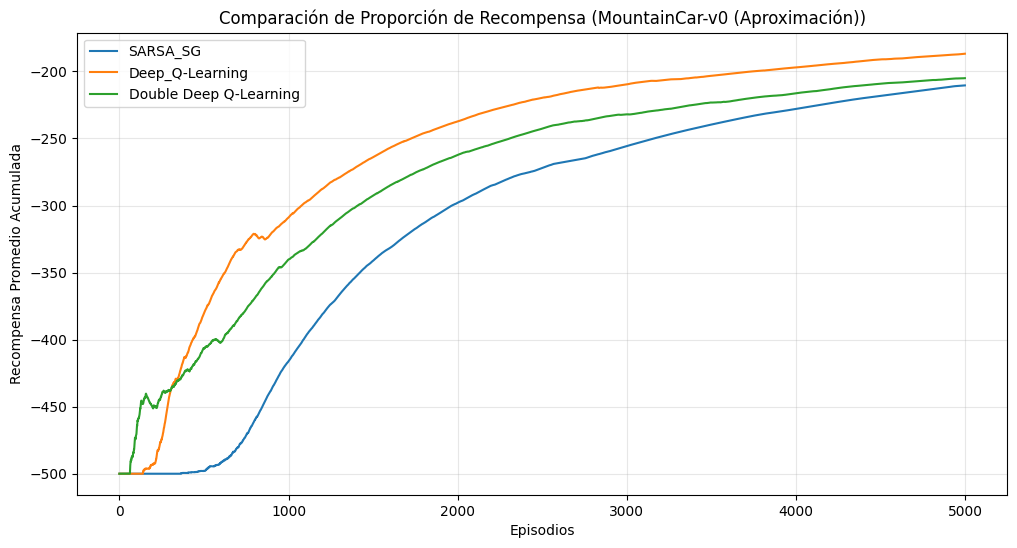

Rendimiento final (Promedio Acumulado) - MountainCar-v0 (Aproximación):
SARSA_SG: -210.4124
Deep_Q-Learning: -186.7876
Double Deep Q-Learning: -205.0126


In [11]:
plot_rewards(results_mountaincar, "MountainCar-v0 (Aproximación)")

En cuanto a la gráfica de la recompensa promedia de cada modelo, podemos sacar lo siguiente:

- **SARSA Semi-gradiente:** Es el algoritmo que más tarda en llegar al objetivo al ser el que más episodios está llegando al máximo número de pasos, debido posiblemente a su alto valor de epsilon inicial y a la naturaleza del algoritmo. Sin embargo, el ritmo de aprendizaje es similar al resto, llegando al mismo nivel de recompensa que el resto de algoritmos.
- **Deep Q-Learning:** Se encuentra en un punto intermedio entre SARSA y Double Q en lo que respecta a encontrar la solución inicial, aun teniendo un ratio de dacay menor que el resto, aunque luego aprende la solución al mismo ritmo que el resto, llegando a superar al resto de modelos.
- **Doble Deep Q-Learning:** Es el modelo que más rápido encuentra la solución, aunque tiene un aprendizaje más lento con respecto a su versión sin ser doble, terminando por debajo de él y casi al mismo nivel que SARSA, aunque con mayor número de episodios se estabilizarían en un mismo punto.

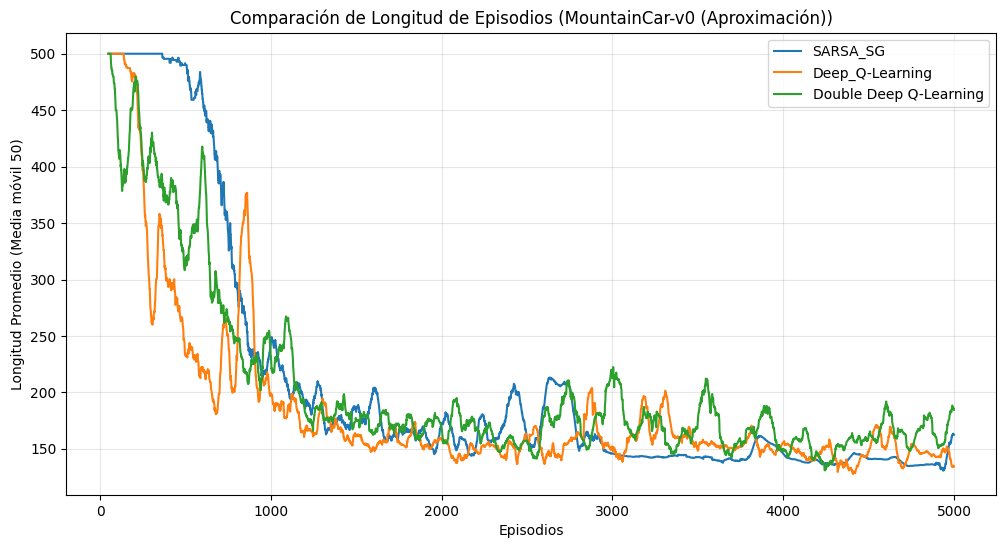

In [12]:
plot_lengths_comparison(results_mountaincar, "MountainCar-v0 (Aproximación)")

En cuanto a la gráfica de la longitud promedia por episodio de cada modelo, podemos sacar lo siguiente:

- **SARSA Semi-gradiente:** Como vimos en la anterior gráfica, es el algoritmo que más episodios tiene con el número máximo de pasos. Sin embargo, a partir de los 500 pasos empieza a encontrar la solución y a aprenderla, terminando con un número de episodios medios similar a los otros algoritmos, siendo incluso más estable al resto.
- **Deep Q-Learning:** Es el segundo algoritmo que más episodios realiza con el máximo número de pasos, aunque es el que más rápido decrece el número de pasos medio. Sin embargo, antes de llegar a los 1000 episodios empieza a aprender un camino erroneo, dando lugar a ese pico de pasos, aunque luego consigue volver a ese camino solución. Creemos que ese pico se debe principalmente al inicio del episodio donde elige ir hacia a la derecha o a la izquierda con probabilidades similares. 
- **Doble Deep Q-Learning:** Es el algoritmo que menos episodios realiza el máximo número de episodios, aunque también es el que tiene un decrecimiento mas inestable con algún que otro pequeño pico.

# **Conclusiones Globales y Propuestas de Estudios Futuros**

### **Conclusiones**

Tras el análisis exhaustivo comparando métodos tabulares (Monte Carlo, TD) en entornos discretos y métodos aproximados (Deep RL, Semi-Gradiente) en entornos continuos, extraemos las siguientes conclusiones:

1.  **Eficiencia de Diferencia Temporal vs Monte Carlo**:
    *   En entornos discretos como **FrozenLake**, los métodos de **Diferencia Temporal (Q-Learning, SARSA)** demuestran una superioridad clara frente a **Monte Carlo**. Convergen mucho más rápido a la política óptima y reducen drásticamente la longitud de los episodios desde etapas tempranas. Monte Carlo, al requerir episodios completos y tener mayor varianza, resulta mucho más lento y costoso computacionalmente para alcanzar el mismo nivel de desempeño.

2.  **Escalabilidad y Complejidad (4x4 vs 8x8)**:
    *   El aumento de dimensionalidad penaliza gravemente a los métodos basados en muestreo puro como Monte Carlo. Mientras que en el mapa 4x4 la diferencia es notable, en el 8x8 se vuelve crítica: los métodos TD logran resolver el laberinto eficientemente, mientras que Monte Carlo lucha por encontrar siquiera una primera ruta exitosa durante gran parte del entrenamiento.

3.  **Aproximación de Funciones en Espacios Continuos (MountainCar)**:
    *   **Double Deep Q-Learning (DDQN)** destaca por ser el algoritmo que **más rápido encuentra una solución viable**, reduciendo el problema de la sobreestimación de valores Q típico de DQN.
    *   **Deep Q-Learning (DQN)**, aunque tarda un poco más en arrancar que su versión doble, muestra una **velocidad de aprendizaje y convergencia final superior** una vez que empieza a optimizar.
    *   **Semi-Gradient SARSA**, al usar una aproximación lineal más simple, es el más lento en "entender" la dinámica del coche para subir la montaña, pasando muchos episodios saturado en el límite de pasos, aunque ofrece una curva de aprendizaje final muy estable y sin las oscilaciones de las redes neuronales profundas.

### **Propuestas de Estudios Futuros**

1.  **Análisis en Entornos Estocásticos**:
    *   Extender la comparativa a versiones estocásticas de los entornos (ej. `is_slippery=True` en FrozenLake). Esto permitiría evaluar la robustez de SARSA (que debería ser más prudente) frente a Q-Learning (que asume determinismo en su maximización) y verificar si Monte Carlo reduce su desventaja al promediar mejor el ruido ambiental.

2.  **Transfer Learning**:
    *   Estudiar si el conocimiento adquirido en entornos pequeños (4x4) puede acelerar el aprendizaje en entornos más grandes (8x8) utilizando técnicas de transferencia de aprendizaje, lo cual sería vital para problemas del mundo real donde entrenar desde cero es costoso.